In [ ]:
import pandas as pd
import re

Log kaydını yükleyip uygun regex'i tanımlayalım

In [ ]:
log_file_path = '/content/drive/MyDrive/Anomally dataset/LOG/aug_sep_oct_2021.log'


regex_pattern = r'^(?P<client>\S+) \S+ (?P<userid>\S+) \[(?P<datetime>[\w:/]+\s[+\-]\d{4})\] "(?P<method>[A-Z]+) (?P<request>[^ "]+)? HTTP/[0-9.]+" (?P<status>[0-9]{3}) (?P<size>[0-9]+|-) "(?P<referer>[^"]*)" "(?P<user_agent>[^"]*)"'


Sutunları tanımlayıp ayrıştırılan verileri doğru sutunlara koyalım

In [ ]:
columns = ['client', 'userid', 'datetime', 'method', 'request', 'status', 'size', 'referer', 'user_agent']


log_data = []
with open(log_file_path, 'r') as file:
    for i, line in enumerate(file):
        if i >= 100000:
            break
        match = re.match(regex_pattern, line)
        if match:
            log_data.append({
                'client': match.group('client'),
                'userid': match.group('userid'),
                'datetime': match.group('datetime'),
                'method': match.group('method'),
                'request': match.group('request'),
                'status': match.group('status'),
                'size': match.group('size'),
                'referer': match.group('referer'),
                'user_agent': match.group('user_agent')
            })
        else:
            print("Error: Line does not match regex pattern:", line)

logs_df = pd.DataFrame(log_data, columns=columns)

Error: Line does not match regex pattern: 27.124.45.147 - - [03/Aug/2021:15:06:16 -0700] "HEAD //index.php?s=index/%5Cthink%5Ctemplate%5Cdriver%5Cfile/write?cacheFile=123.php&content=%3C?php%20@$c%20=%20@str_pad(@$_POST%5B1%5D,%201,%20%22%22);eval(%27%27%20.%20$c);%20?%3E HTTP/1.1" 418 136 "http://www.secrepo.com//index.php?s=index/\\think\\template\\driver\\file/write?cacheFile=123.php&content=<?php%20@$c%20=%20@str_pad(@$_POST[1],%201,%20\"\");eval(%27%27%20.%20$c);%20?>" "Mozilla/5.0 (compatible; Baiduspider/2.0; +http://www.baidu.com/search/spider.html" 

Error: Line does not match regex pattern: 27.124.45.147 - - [03/Aug/2021:15:06:16 -0700] "HEAD //index.php?function=call_user_func_array&s=/Index/%5Cthink%5Capp/invokefunction&vars%5B0%5D=file_put_contents&vars%5B1%5D%5B%5D=123.php&vars%5B1%5D%5B%5D=%3C?php%20@$c%20=%20@str_pad(@$_POST%5B1%5D,%201,%20%22%22);eval(%27%27%20.%20$c);%20?%3E HTTP/1.1" 418 136 "http://www.secrepo.com//index.php?function=call_user_func_array&s=/Index/\\

In [ ]:
logs_df = pd.DataFrame(log_data, columns=columns)


In [ ]:
logs_df.head()


,client,userid,datetime,method,request,status,size,referer,user_agent
0,45.12.90.137,-,01/Aug/2021:03:03:55 -0700,GET,/,200,12883,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...
1,45.12.90.137,-,01/Aug/2021:03:03:55 -0700,GET,/robots.txt,200,377,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...
2,45.12.90.137,-,01/Aug/2021:03:03:56 -0700,GET,/css/style.css,404,328,http://www.secrepo.com/,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...
3,45.12.90.137,-,01/Aug/2021:03:03:57 -0700,GET,/twitter-icon.png,200,27916,http://www.secrepo.com/,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...
4,45.12.90.137,-,01/Aug/2021:03:03:57 -0700,GET,/GitHub-Mark.png,200,7556,http://www.secrepo.com/,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...


In [ ]:
logs_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99978 entries, 0 to 99977
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   client      99978 non-null  object
 1   userid      99978 non-null  object
 2   datetime    99978 non-null  object
 3   method      99978 non-null  object
 4   request     99978 non-null  object
 5   status      99978 non-null  object
 6   size        99978 non-null  object
 7   referer     99978 non-null  object
 8   user_agent  99978 non-null  object
dtypes: object(9)
memory usage: 6.9+ MB


In [ ]:

from datetime import datetime
import pytz

Zamanı regex ile ayıralım

In [ ]:
def parse_datetime(x):
    try:
        dt = datetime.strptime(x[1:-7], '%d/%b/%Y:%H:%M:%S')
        dt_tz = int(x[-6:-3])*60+int(x[-3:-1])
        return dt.replace(tzinfo=pytz.FixedOffset(dt_tz))
    except ValueError:
        return '-'

Gerekli sutunları doğru formata sokalım

In [ ]:
logs_df['status'] = logs_df['status'].astype(int)
logs_df['size'] = logs_df['size'].astype(int)
logs_df['datetime'] = logs_df['datetime'].apply(parse_datetime)

In [ ]:
logs_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99978 entries, 0 to 99977
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   client      99978 non-null  object
 1   userid      99978 non-null  object
 2   datetime    99978 non-null  object
 3   method      99978 non-null  object
 4   request     99978 non-null  object
 5   status      99978 non-null  int64 
 6   size        99978 non-null  int64 
 7   referer     99978 non-null  object
 8   user_agent  99978 non-null  object
dtypes: int64(2), object(7)
memory usage: 6.9+ MB


Gereksiz olan userid sutununu silelim

In [ ]:
logs_df.drop(columns=['userid'], inplace=True)


In [ ]:

duplicate_count = logs_df.duplicated().sum()

print("Number of duplicates:", duplicate_count)

Number of duplicates: 10974


Aynı olan satırları temizleme

In [ ]:
logs_df = logs_df.drop_duplicates()


In [ ]:
logs_df.head()


,client,datetime,method,request,status,size,referer,user_agent
0,45.12.90.137,2021-08-01 03:03:05+01:10,GET,/,200,12883,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...
1,45.12.90.137,2021-08-01 03:03:05+01:10,GET,/robots.txt,200,377,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...
2,45.12.90.137,2021-08-01 03:03:05+01:10,GET,/css/style.css,404,328,http://www.secrepo.com/,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...
3,45.12.90.137,2021-08-01 03:03:05+01:10,GET,/twitter-icon.png,200,27916,http://www.secrepo.com/,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...
4,45.12.90.137,2021-08-01 03:03:05+01:10,GET,/GitHub-Mark.png,200,7556,http://www.secrepo.com/,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...


Zamanı doğru formata sokma

In [ ]:

logs_df = logs_df[logs_df['datetime'] != '-']

logs_df['datetime'] = pd.to_datetime(logs_df['datetime'])



# Kategorik 'request' sütununu sayısal verilere dönüştürme

In [ ]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
logs_df['request_encoded'] = le.fit_transform(logs_df['request'])


In [ ]:
logs_df['timestamp'] = logs_df['datetime'].astype(int) / 10**9


logs_df[['datetime', 'timestamp']].head()

,datetime,timestamp
0,2021-08-01 03:03:05+01:10,1.627783e+09
1,2021-08-01 03:03:05+01:10,1.627783e+09
2,2021-08-01 03:03:05+01:10,1.627783e+09
3,2021-08-01 03:03:05+01:10,1.627783e+09
4,2021-08-01 03:03:05+01:10,1.627783e+09


İp adreslerini encode edelim

In [ ]:

le_ip = LabelEncoder()
logs_df['client_encoded'] = le_ip.fit_transform(logs_df['client'])

logs_df[['client', 'client_encoded']].head()


,client,client_encoded
0,45.12.90.137,4570
1,45.12.90.137,4570
2,45.12.90.137,4570
3,45.12.90.137,4570
4,45.12.90.137,4570


Features'leri seçme

In [ ]:

input_features = ['timestamp', 'client_encoded', 'status', 'size', 'request_encoded']

X = logs_df[input_features]


Veriyi bölelim

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.2, shuffle=False)

X_train.head(), X_test.head()


(      timestamp  client_encoded  status   size  request_encoded
 0  1.627783e+09            4570     200  12883                0
 1  1.627783e+09            4570     200    377             1962
 2  1.627783e+09            4570     404    328             1142
 3  1.627783e+09            4570     200  27916             7246
 4  1.627783e+09            4570     200   7556              529,
           timestamp  client_encoded  status   size  request_encoded
 75428  1.633569e+09            3873     200    690             1059
 75429  1.633570e+09            5888     200  13186                0
 75430  1.633570e+09             476     200  49133                0
 75431  1.633570e+09             476     404    269             1109
 75432  1.633570e+09             476     404    284             1108)

In [ ]:
import numpy as np


X_train_reshaped = np.array(X_train)
X_train_reshaped = np.reshape(X_train_reshaped, (X_train_reshaped.shape[0], X_train_reshaped.shape[1], 1))

X_test_reshaped = np.array(X_test)
X_test_reshaped = np.reshape(X_test_reshaped, (X_test_reshaped.shape[0], X_test_reshaped.shape[1], 1))

X_train_reshaped.shape, X_test_reshaped.shape


((62661, 5, 1), (15666, 5, 1))

Veri Normalizasyonu

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = np.reshape(X_scaled, (X_scaled.shape[0], X_scaled.shape[1], 1))

X_train_scaled, X_test_scaled = train_test_split(X_scaled, test_size=0.2, shuffle=False)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam

# Encoder
inputs = Input(shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))  # (timesteps, features)

# LSTM Encoder
encoded = LSTM(64, activation='relu', return_sequences=False)(inputs)  # Daha düşük nöron sayısı
encoded = RepeatVector(X_train_scaled.shape[1])(encoded)  # Zaman dilimlerine tekrar

# Decoder
decoded = LSTM(64, activation='relu', return_sequences=True)(encoded)
decoded = TimeDistributed(Dense(X_train_scaled.shape[2]))(decoded)  # Her zaman diliminde yeniden yapılandırma

# Autoencoder modelini oluşturma
autoencoder = Model(inputs, decoded)

# Modeli derlerken optimizer ve loss fonksiyonunu belirleyelim
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Modeli eğitme
history = autoencoder.fit(X_train_scaled, X_train_scaled,
                          epochs=5,
                          batch_size=32,
                          validation_data=(X_test_scaled, X_test_scaled))


Epoch 1/5
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 0.0555 - val_loss: 0.0024
Epoch 2/5
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 9.8604e-04 - val_loss: 5.8612e-04
Epoch 3/5
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5.0457e-04 - val_loss: 3.9856e-04
Epoch 4/5
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 2.9082e-04 - val_loss: 3.2647e-04
Epoch 5/5
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 2.7779e-04 - val_loss: 1.3848e-04


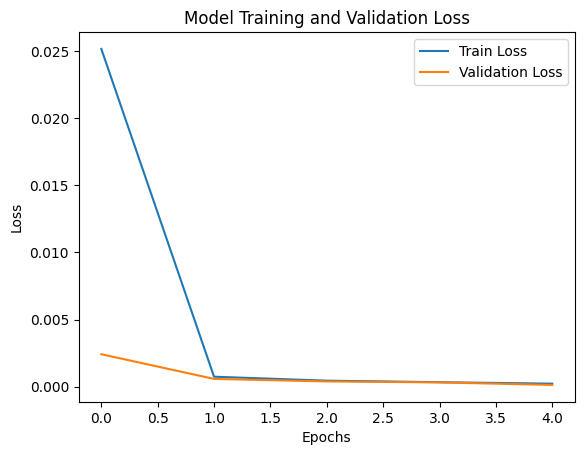

In [ ]:
import matplotlib.pyplot as plt

# Eğitim kaybını ve doğrulama kaybını görselleştirelim
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


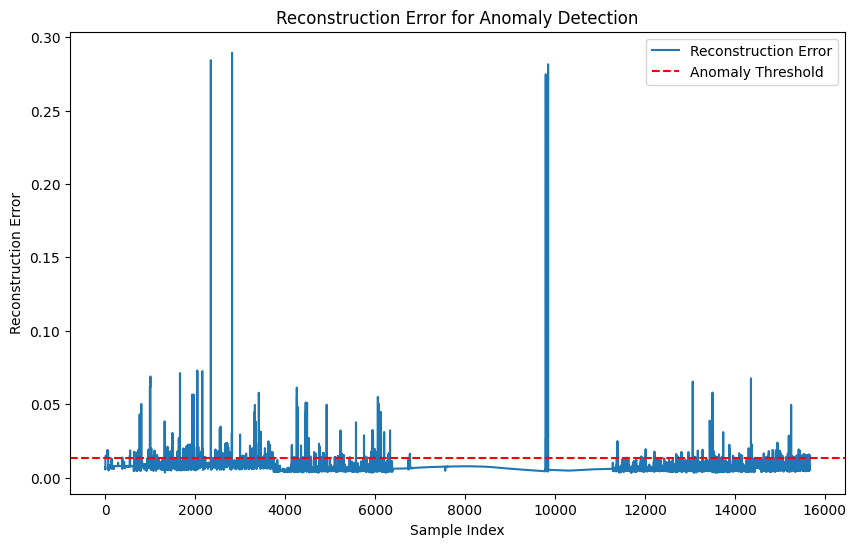

In [ ]:
# Modelin tahminlerini yapalım
predictions = autoencoder.predict(X_test_scaled)

# Yeniden yapılandırma hatasını hesaplayalım
reconstruction_error = np.mean(np.abs(predictions - X_test_scaled), axis=1)

# Eşik belirleme ve anomali tespiti
threshold = np.percentile(reconstruction_error, 95)  # 95. percentil eşik olarak alınabilir

# Anomalileri tespit edelim
anomalies = reconstruction_error > threshold

# Anomalileri görselleştirelim
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Anomaly Threshold')
plt.legend()
plt.title('Reconstruction Error for Anomaly Detection')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Modelin tahminlerini al
X_train_pred = autoencoder.predict(X_train_scaled)
X_test_pred = autoencoder.predict(X_test_scaled)

# Eğitim ve test hatalarını hesapla
train_loss = np.mean(np.abs(X_train_scaled - X_train_pred), axis=(1, 2))
test_loss = np.mean(np.abs(X_test_scaled - X_test_pred), axis=(1, 2))

# Eşik değerini belirle
threshold = np.percentile(train_loss, 95)  # Eğitim verisinin %95'inin altındaki hata, normal olarak kabul edilir

# Anormal verileri belirleme (eğitim verisi üzerinden)
y_train_pred = (train_loss > threshold).astype(int)  # 1: Anormal, 0: Normal
y_test_pred = (test_loss > threshold).astype(int)


print(f"Threshold for anomaly detection: {threshold}")
print(f"Predicted anomalies in test data: {np.sum(y_test_pred)}")


1959/1959 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Threshold for anomaly detection: 0.011663767574261335
Predicted anomalies in test data: 1041


1959/1959 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Train anomalies detected: 200
Test anomalies detected: 86


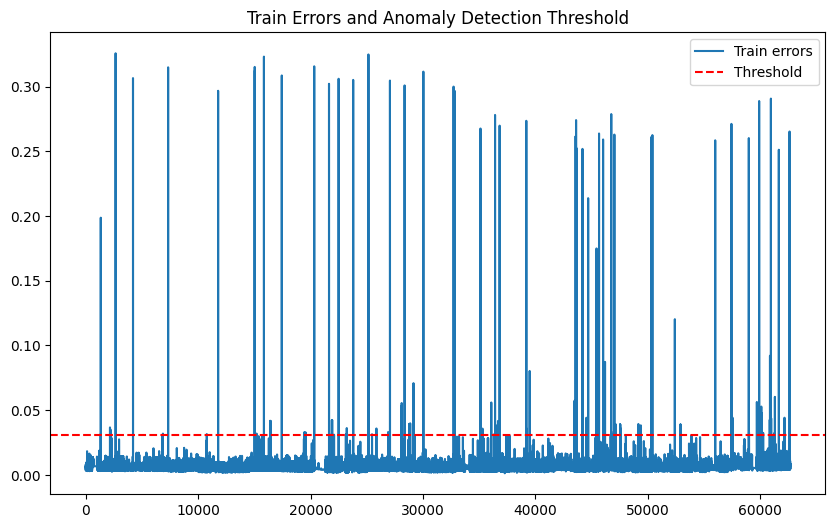

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Eğitim sırasında modelin hatalarını alalım
train_pred = autoencoder.predict(X_train_scaled)
test_pred = autoencoder.predict(X_test_scaled)

# Eğitim verisinin hatalarını hesaplayalım
train_errors = np.mean(np.abs(train_pred - X_train_scaled), axis=(1, 2))
test_errors = np.mean(np.abs(test_pred - X_test_scaled), axis=(1, 2))

# Hata değerlerinin ortalaması
threshold = np.mean(train_errors) + 3 * np.std(train_errors)  # 3-sigma kuralı ile eşik belirleme

# Anomali olarak tespit edilen veriler
train_anomalies = train_errors > threshold
test_anomalies = test_errors > threshold

print(f'Train anomalies detected: {np.sum(train_anomalies)}')
print(f'Test anomalies detected: {np.sum(test_anomalies)}')




plt.figure(figsize=(10, 6))
plt.plot(train_errors, label='Train errors')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.title('Train Errors and Anomaly Detection Threshold')
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# LabelEncoder'ı tersine çevirmek için fit_transform kullandık.
# 'client_encoded' ve 'request_encoded' sütunları üzerinden tekrar orijinal verilere ulaşmak için
client_decoder = le_ip.inverse_transform
request_decoder = le.inverse_transform

# Anomalileri tespit ettiğimiz veri kümesindeki anomali satırlarını decode edelim
train_anomalies_df = X_train[train_anomalies]
test_anomalies_df = X_test[test_anomalies]

# 'client' ve 'request' sütunlarını decode et
train_anomalies_df['client'] = client_decoder(train_anomalies_df['client_encoded'])
train_anomalies_df['request'] = request_decoder(train_anomalies_df['request_encoded'])

test_anomalies_df['client'] = client_decoder(test_anomalies_df['client_encoded'])
test_anomalies_df['request'] = request_decoder(test_anomalies_df['request_encoded'])

# Anomali olarak tespit edilen satırları yazdıralım
print(f"Anomalies detected in train data:")
print(train_anomalies_df[['client', 'request', 'status', 'size']].head())  # Anomali satırlarını yazdır

print(f"\nAnomalies detected in test data:")
print(test_anomalies_df[['client', 'request', 'status', 'size']].head())  # Anomali satırlarını yazdır



Anomalies detected in train data:
             client                                     request  status  \
1343  192.99.18.108                     /maccdc2012/conn.log.gz     200   
1352  192.99.18.108                     /maccdc2012/http.log.gz     200   
2188  62.201.255.17  /Security-Data-Analysis/Lab_1/conn.log.zip     206   
2195  62.201.255.17  /Security-Data-Analysis/Lab_1/conn.log.zip     206   
2204  62.201.255.17  /Security-Data-Analysis/Lab_1/conn.log.zip     206   

           size  
1343  360082720  
1352   56420965  
2188   72264418  
2195   70472416  
2204   68124456  

Anomalies detected in test data:
               client         request  status  size
83436  103.131.95.124               /     301   419
83473   103.18.170.31  /css/style.css     404   305
83665   101.34.170.87    /wwwroot.rar     404   265
83666   101.34.170.87    /wwwroot.zip     404   231
83667   101.34.170.87        /www.rar     404   231


<ipython-input-28-c7740674f065>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_anomalies_df['client'] = client_decoder(train_anomalies_df['client_encoded'])
<ipython-input-28-c7740674f065>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_anomalies_df['request'] = request_decoder(train_anomalies_df['request_encoded'])
<ipython-input-28-c7740674f065>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [ ]:
# Modeli .h5 formatında kaydedelim
autoencoder.save('/content/drive/MyDrive/Davranistespiti_model.h5')

print("Model başarıyla kaydedildi!")


Model başarıyla kaydedildi!
